# Introducción a la Ingeniería de Datos

## Trabajo Práctico N.º 3
### Análisis multivariante del ecosistema global de noticias (GDELT 2.0 / CAMEO)

**Autor:** Matías R. Pretel

## Instrucciones de la actividad

**Trabajo práctico 3**

**IMPORTANTE:** Al utilizar herramientas de inteligencia artificial deben indicar qué IA están usando y con qué propósito. Por ejemplo: "Claude Opus 4.6" para "mejorar redacción de textos" o "Chat GPT 5.6" para "crear código fuente".

**Introducción:**

En el TP1 procesaron el flujo de datos de GDELT 2.0. En el TP2 crearon un diseño de almacén de datos estructurado de forma tal que permita responder preguntas clave del negocio periodístico. Ahora, el equipo de Investigación & Ciencia de Datos de un Medio Internacional de Noticias requiere analizar el comportamiento multivariante del ecosistema global de noticias. A diferencia del conjunto de datos Iris, donde la dimensionalidad es baja y las distribuciones son homogéneas, el flujo de GDELT 2.0 es ruidoso, disperso y de alta dimensionalidad.

**Recursos:**

- Lista de URLs con actualizaciones cada 15 minutos https://data.gdeltproject.org/gdeltv2/masterfilelist.txt .
- URL oficial del libro de códigos de GDELT 2.0 https://data.gdeltproject.org/documentation/GDELT-Event_Codebook-V2.0.pdf
- URL de la documentación en texto/HTML donde se enuncian los campos https://gdeltproject.org/data/documentation/CAMEO.Manual.1.1b3.pdf

**Requisitos y Preguntas de Investigación:**

El análisis multivariante debe estructurarse para responder las siguientes 4 preguntas clave del análisis mediático e inteligencia global:

1. **Perfil Multivariante de eventos:** ¿Cómo se caracterizan simultáneamente los eventos mediante sus vectores de medias?
2. **Topología de Cobertura Mediática:** ¿Qué perfiles de eventos son más similares y disímiles al comparar sus distancias?
3. **Estructura de Correlación:** ¿Existen asociaciones entre las variables de los eventos?
4. **Compresión del Ecosistema de Noticias:** ¿Cuántas componentes principales pueden resumir la varianza total de los datos y cómo se interpretan conceptualmente los pesos en dichas componentes?

**Actividades:**

1) Ingesta de datos
   - **Organización:** Extiendan su diseño del almacén de datos del TP2 para incluir: actores 1 y 2, el tipo de interacción, la región donde se produce el evento, el tono y el impacto estimado por Goldstein.
   - **Reducción de Cardinalidad:** Agrupen las categorías marginales (frecuencia menor al 5% de la muestra) bajo la etiqueta 'OTHER' antes de codificar, para prevenir la inflación de dimensiones nulas.
   - **Codifiquen como variables indicadoras:** Transformen las variables categóricas en variables indicadoras (dummy).
   - **Construcción de la Matriz de Datos:** Creen un DataFrame integrado que combine las variables continuas y las variables indicadoras (dummy) recién generadas.

2) Descripción Multivariante
   - **Vector de Medias:** calculen el vector de medias global y calculen un vectores de medias por país. Calculen las distancias entre todos los vectores (global vs país y país vs país).
   - **Matriz de Correlaciones:** Construyan mapas de calor e interpreten la matriz de correlación a nivel global y por país.

3) Reducción de Dimensionalidad e Interpretación de Componentes
   - **Ajuste del Modelo:** Apliquen la técnica de Análisis por Componentes Principales (ACP) sobre la matriz de datos con las características escaladas.
   - **Análisis de Varianza Explicada:** Generen el gráfico de sedimentación (Scree Plot) y determinen la cantidad mínima de componentes principales requeridas.
   - **Interpretación de Componentes:** Analicen e interpreten los vectores de carga (loadings) de las componentes principales elegidas. Asignen un nombre o dimensión conceptual a cada una según las variables con mayor peso relativo.
   - **Visualización Biplot:** Proyecten las observaciones en el plano de las dos primeras componentes principales (PC1 vs. PC2). Identifiquen patrones de agrupamiento o presencia de valores atípicos (outliers) multivariantes.

### Uso de inteligencia artificial

Se utilizó **Claude Opus 5.5** (Anthropic) con los siguientes propósitos:

- Crear la estructura de carpetas del TP y el código de ingesta (`src/`): descarga de la muestra, almacén de datos en SQLite (esquema, carga y consultas), reducción de cardinalidad, codificación indicadora y armado de la matriz de datos.
- Asignar los códigos de país FIPS de GDELT a regiones y agrupar los tipos de actor CAMEO en categorías.
- Escribir el código de la descripción multivariante (medias, distancias, correlaciones y gráficos) y un primer borrador de su interpretación.
- Escribir el código del ACP (análisis paralelo, outliers, scree plot, loadings y biplot) y un primer borrador de la interpretación de las componentes y de las conclusiones.

La lógica reutilizable vive en el paquete [`src/`](../src); este notebook sólo la orquesta:

1. `src.master_list` y `src.fetch`: recorren la lista maestra en streaming y descargan los archivos de eventos de la muestra, leyendo sólo las columnas necesarias (igual que en el TP1).
2. `src.pipeline`: descarga la muestra en paralelo y la guarda en `data/processed/eventos.parquet`.
3. `src.regions`: tabla de países FIPS con su región.
4. `src.warehouse`: almacén de datos en SQLite (esquema, carga y consultas).
5. `src.features`: reducción de cardinalidad, variables indicadoras y matriz de datos.
6. `src.multivariate`: vectores de medias, distancias y correlaciones.
7. `src.pca`: ACP, análisis paralelo y outliers multivariantes.
8. `src.plots`: gráficos (se guardan en `data/processed/figures/`).

In [1]:
import sys
from pathlib import Path

# Permite importar el paquete `src` del TP (la carpeta que contiene este notebook).
TP_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src").is_dir())
if str(TP_ROOT) not in sys.path:
    sys.path.insert(0, str(TP_ROOT))

import numpy as np
import pandas as pd

from src import plots
from src.config import (
    ACTOR_CATEGORIES,
    CAMEO_ROOT_LABELS,
    CATEGORICAL,
    CONTINUOUS,
    COUNTRY,
    END_DATE,
    MATRIX_PARQUET,
    PCA_EXCLUDED,
    START_DATE,
)
from src.features import build_events, build_matrix, encode_dummies, reduce_cardinality
from src.multivariate import (
    GLOBAL,
    correlation_distance,
    correlation_pairs,
    country_correlations,
    distance_matrix,
    mean_vectors,
    pairs_by_country,
    profile_columns,
    source_variable,
    standardize_means,
    top_countries,
    variable_label,
)
from src.pca import multivariate_outliers, parallel_analysis, retention_criteria, run_pca
from src.pipeline import download_sample
from src.regions import load_fips_lookup
from src.warehouse import ANALYSIS_QUERY, SCHEMA, load_warehouse, merge_analysis_frame, query

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 250)
plots.set_style()

## Actividad 1: Ingesta de datos

### 1.1 Organización: extensión del almacén del TP2

El almacén se implementa en **SQLite** (`data/processed/almacen.sqlite`, código en `src/warehouse.py`). Es un esquema estrella que extiende el modelo dimensional simplificado del TP2 (tiempo, geografía, tipo de actor y temas CAMEO alrededor de una tabla de hechos) con lo que pide este TP:

- **Actores 1 y 2**: el hecho apunta dos veces a `dim_tipo_actor` (`actor1_tipo_id`, `actor2_tipo_id`). Es una *dimensión de rol múltiple*: una sola tabla de tipos de actor que cumple dos roles.
- **Tipo de interacción**: `dim_cameo` guarda la jerarquía CAMEO completa de cada código (evento → base → raíz) y su clase general (`quad_class`). El análisis usa la raíz.
- **Región**: `dim_geografia` agrega la región a cada país.
- **Tono e impacto de Goldstein**: son métricas de `fact_evento`, junto con las de cobertura (menciones, fuentes y artículos).

A diferencia del modelo del TP2, que agrega las métricas por combinación de dimensiones, **el grano de la tabla de hechos es el evento**: una fila por `GLOBALEVENTID`. El análisis multivariante trabaja sobre observaciones individuales, y un agregado perdería la variabilidad entre eventos.

```
                      dim_tiempo                         dim_geografia
                 ┌──────────────────┐                ┌──────────────────┐
                 │ PK fecha_key     │                │ PK geo_id        │
                 │    fecha, anio   │                │    pais_cod (UK) │
                 │    trimestre     │                │    pais_nombre   │
                 │    mes, dia      │                │    region        │
                 │    dia_semana    │                └────────┬─────────┘
                 │    es_fin_semana │                         │ 0..1
                 └────────┬─────────┘                         │
                          │ 1          fact_evento            │
                          │      ┌──────────────────────┐     │
                          └─────<│ PK evento_id         │>────┘
                                 │ FK fecha_key         │
     dim_tipo_actor              │ FK geo_id            │            dim_cameo
 ┌──────────────────┐   actor 1  │ FK actor1_tipo_id    │   ┌──────────────────────┐
 │ PK tipo_actor_id │───────────<│ FK actor2_tipo_id    │   │ PK cameo_cod         │
 │    tipo_cod (UK) │───────────<│ FK cameo_cod         │>──│    base_cod          │
 │    categoria     │   actor 2  │    escala_goldstein  │   │    raiz_cod          │
 └──────────────────┘            │    tono_promedio     │   │    quad_class        │
                                 │    num_menciones     │   │    raiz_desc         │
                                 │    num_fuentes       │   │    quad_class_desc   │
                                 │    num_articulos     │   └──────────────────────┘
                                 └──────────────────────┘
```

**Tabla 1.** Variables del análisis y su lugar en el almacén.

| Variable | Tabla | Atributo | Campo de GDELT 2.0 |
|---|---|---|---|
| Categoría del actor 1 | `dim_tipo_actor` (vía `actor1_tipo_id`) | `categoria` | `Actor1Code`, `Actor1Type1Code` |
| Categoría del actor 2 | `dim_tipo_actor` (vía `actor2_tipo_id`) | `categoria` | `Actor2Code`, `Actor2Type1Code` |
| Tipo de interacción | `dim_cameo` | `raiz_cod` | `EventCode`, `EventBaseCode`, `EventRootCode`, `QuadClass` |
| País y región del evento | `dim_geografia` | `pais_cod`, `pais_nombre`, `region` | `ActionGeo_CountryCode` |
| Fecha del evento | `dim_tiempo` | `fecha` y sus atributos | `SQLDATE` |
| Tono | `fact_evento` | `tono_promedio` | `AvgTone` |
| Impacto (Goldstein) | `fact_evento` | `escala_goldstein` | `GoldsteinScale` |
| Menciones, fuentes y artículos | `fact_evento` | `num_menciones`, `num_fuentes`, `num_articulos` | `NumMentions`, `NumSources`, `NumArticles` |

Dos atributos no vienen en GDELT y se derivan al cargar las dimensiones:

- **`dim_geografia.region`**: GDELT sólo informa el país, con código FIPS 10-4. Cada código se asigna a una de las 7 regiones del Banco Mundial (`src/regions.py`). Los códigos que no son países (océanos, Antártida) quedan en `Sin región`.
- **`dim_tipo_actor.categoria`**: GDELT informa hasta 3 tipos CAMEO por actor (`GOV`, `COP`, `BUS`, …). Se usa el primero y se lo agrupa en 6 categorías (Tabla 2). La dimensión tiene además dos filas que no son tipos: `SIN_ACTOR` (el evento no tiene ese actor) y `SIN_TIPO` (el actor existe, pero CAMEO no le asignó un tipo; suele ser un país o una persona). Así, la FK del actor nunca es nula.

In [2]:
pd.DataFrame(
    [(categoria, codigos.replace(" ", ", ")) for categoria, codigos in ACTOR_CATEGORIES.items()],
    columns=["categoria", "tipos CAMEO"],
).style.set_caption("Tabla 2. Agrupación de los tipos CAMEO de actor").hide(axis="index")

categoria,tipos CAMEO
Estado y política,"GOV, LEG, JUD, UIS, OPP, ELI"
Seguridad,"COP, MIL, SPY"
Grupos armados y crimen,"CRM, UAF, REB, INS, SEP, RAD"
Economía,"BUS, MNC, AGR"
Sociedad civil,"CVL, EDU, MED, HLH, LAB, REF, HRI, ENV, SET, IMG"
Organizaciones,"IGO, NGO, INT"


### 1.2 Muestra

Se toma una semana completa, del lunes 28 de septiembre al domingo 4 de octubre de 2026, y de cada hora el archivo de las hh:00 (1 de cada 4 archivos de 15 minutos). Así todos los días de la semana y todas las horas del día pesan igual. Los eventos crudos quedan en `data/processed/eventos.parquet` como área de *staging*, antes de cargarlos al almacén.

In [3]:
eventos_crudos = download_sample()
print(f"Muestra: {START_DATE} a {END_DATE}, {len(eventos_crudos):,} eventos")
eventos_crudos.head()

Muestra: 20260928 a 20261004, 173,928 eventos


,GLOBALEVENTID,SQLDATE,Actor1Code,Actor1Type1Code,Actor2Code,Actor2Type1Code,EventCode,EventBaseCode,EventRootCode,QuadClass,GoldsteinScale,NumMentions,NumSources,NumArticles,AvgTone,ActionGeo_CountryCode
0,1325186209,20160930,<NA>,<NA>,ARE,<NA>,036,036,03,1,4.0,20,1,10,-1.965812,AE
1,1325186210,20160930,<NA>,<NA>,MIL,MIL,190,190,19,4,-10.0,10,1,10,-2.356902,US
2,1325186211,20160930,ARE,<NA>,<NA>,<NA>,036,036,03,1,4.0,20,1,10,-1.965812,AE
3,1325186212,20160930,MIL,MIL,<NA>,<NA>,190,190,19,4,-10.0,10,1,10,-2.356902,US
4,1325186213,20250928,<NA>,<NA>,ITA,<NA>,042,042,04,1,1.9,2,1,2,0.324939,US


### 1.3 Carga del almacén

`load_warehouse` crea la base desde cero con el esquema de abajo y carga primero las dimensiones y después el hecho. Las claves foráneas están activadas (`PRAGMA foreign_keys = ON`): si un hecho apuntara a una fila inexistente de una dimensión, la carga fallaría.

In [4]:
print(SCHEMA)


CREATE TABLE dim_tiempo (
    fecha_key        INTEGER PRIMARY KEY,  -- YYYYMMDD
    fecha            TEXT    NOT NULL,     -- ISO 8601
    anio             INTEGER NOT NULL,
    trimestre        INTEGER NOT NULL,
    mes              INTEGER NOT NULL,
    dia              INTEGER NOT NULL,
    dia_semana       INTEGER NOT NULL,     -- 1 = lunes ... 7 = domingo
    es_fin_de_semana INTEGER NOT NULL      -- 0 / 1
);

CREATE TABLE dim_geografia (
    geo_id      INTEGER PRIMARY KEY,
    pais_cod    TEXT NOT NULL UNIQUE,      -- FIPS 10-4 (ActionGeo_CountryCode)
    pais_nombre TEXT NOT NULL,
    region      TEXT NOT NULL              -- Banco Mundial
);

CREATE TABLE dim_tipo_actor (
    tipo_actor_id INTEGER PRIMARY KEY,
    tipo_cod      TEXT NOT NULL UNIQUE,    -- Actor*Type1Code, SIN_TIPO o SIN_ACTOR
    categoria     TEXT NOT NULL            -- agrupación para el análisis
);

CREATE TABLE dim_cameo (
    cameo_cod       TEXT PRIMARY KEY,      -- EventCode
    base_cod        TEXT N

In [5]:
filas = load_warehouse(eventos_crudos, load_fips_lookup())
pd.Series(filas, name="filas").to_frame().style.format("{:,}").set_caption("Tabla 3. Filas cargadas por tabla")

,filas
dim_tiempo,35
dim_geografia,230
dim_tipo_actor,33
dim_cameo,215
fact_evento,"173,928"


Con el almacén cargado ya se puede consultar como cualquier almacén dimensional. Por ejemplo, el tono y el impacto promedio por región y clase de evento:

In [6]:
query("""
SELECT g.region,
       c.quad_class_desc        AS clase,
       COUNT(*)                 AS eventos,
       ROUND(AVG(f.tono_promedio), 2)    AS tono,
       ROUND(AVG(f.escala_goldstein), 2) AS goldstein
FROM fact_evento AS f
JOIN dim_geografia AS g ON g.geo_id    = f.geo_id
JOIN dim_cameo     AS c ON c.cameo_cod = f.cameo_cod
GROUP BY g.region, c.quad_class
ORDER BY g.region, c.quad_class
""").head(8)

,region,clase,eventos,tono,goldstein
0,América Latina y Caribe,Cooperación verbal,3841,-1.31,2.26
1,América Latina y Caribe,Cooperación material,643,-2.36,5.10
2,América Latina y Caribe,Conflicto verbal,842,-3.60,-3.38
3,América Latina y Caribe,Conflicto material,940,-4.85,-7.30
4,Asia Oriental y Pacífico,Cooperación verbal,11167,-0.26,2.40
5,Asia Oriental y Pacífico,Cooperación material,1915,-0.98,5.13
6,Asia Oriental y Pacífico,Conflicto verbal,1921,-2.13,-3.44
7,Asia Oriental y Pacífico,Conflicto material,1626,-3.77,-7.61


### 1.4 Del almacén al DataFrame

La tabla de eventos del análisis es una vista plana del esquema estrella: una fila por hecho, con los atributos de las dimensiones ya resueltos. Se obtiene con un JOIN del hecho con sus dimensiones; `dim_tipo_actor` entra dos veces, con un alias por rol (`a1`, `a2`). El JOIN interno con `dim_geografia` descarta los eventos sin país de la acción, porque no se los puede asignar a un país ni a una región.

In [7]:
print(ANALYSIS_QUERY)
eventos_join = query(ANALYSIS_QUERY)


SELECT
    f.evento_id,
    t.fecha,
    g.pais_cod         AS pais,
    g.pais_nombre,
    g.region,
    a1.categoria       AS actor1_categoria,
    a2.categoria       AS actor2_categoria,
    c.raiz_cod         AS interaccion,
    f.escala_goldstein AS goldstein,
    f.tono_promedio    AS tono,
    f.num_menciones,
    f.num_fuentes,
    f.num_articulos
FROM fact_evento AS f
JOIN dim_tiempo     AS t  ON t.fecha_key      = f.fecha_key
JOIN dim_geografia  AS g  ON g.geo_id         = f.geo_id
JOIN dim_tipo_actor AS a1 ON a1.tipo_actor_id = f.actor1_tipo_id
JOIN dim_tipo_actor AS a2 ON a2.tipo_actor_id = f.actor2_tipo_id
JOIN dim_cameo      AS c  ON c.cameo_cod      = f.cameo_cod
WHERE f.escala_goldstein IS NOT NULL
  AND f.tono_promedio IS NOT NULL
ORDER BY f.evento_id



La misma tabla se puede armar en pandas, leyendo cada tabla del almacén y uniéndolas con `pd.merge` (`merge_analysis_frame`). Las dos vías dan exactamente el mismo resultado:

In [8]:
eventos_merge = merge_analysis_frame()
print("¿JOIN en SQL == merge en pandas?", eventos_join.equals(eventos_merge))

descartados = len(eventos_crudos) - len(eventos_join)
print(f"Eventos descartados (sin país): {descartados:,} ({descartados / len(eventos_crudos):.1%})")
print(f"Eventos del análisis: {len(eventos_join):,}")

¿JOIN en SQL == merge en pandas? True
Eventos descartados (sin país): 4,969 (2.9%)
Eventos del análisis: 168,959


`build_events` deja la tabla lista para el análisis. Las métricas de cobertura son conteos con una cola larga a la derecha (la mayoría de los eventos tiene pocas menciones y unos pocos tienen cientos), así que entran en escala `log(1 + x)`; así, un puñado de eventos muy cubiertos no domina las medias ni las correlaciones.

In [9]:
eventos = build_events(eventos_join)
eventos.head()

,evento_id,fecha,pais,pais_nombre,region,actor1_categoria,actor2_categoria,interaccion,goldstein,tono,log_menciones,log_fuentes,log_articulos
0,1325186209,2016-09-30,AE,United Arab Emirates,Medio Oriente y Norte de África,SIN_ACTOR,SIN_TIPO,03,4.0,-1.965812,3.044522,0.693147,2.397895
1,1325186210,2016-09-30,US,United States,Norteamérica,SIN_ACTOR,Seguridad,19,-10.0,-2.356902,2.397895,0.693147,2.397895
2,1325186211,2016-09-30,AE,United Arab Emirates,Medio Oriente y Norte de África,SIN_TIPO,SIN_ACTOR,03,4.0,-1.965812,3.044522,0.693147,2.397895
3,1325186212,2016-09-30,US,United States,Norteamérica,Seguridad,SIN_ACTOR,19,-10.0,-2.356902,2.397895,0.693147,2.397895
4,1325186213,2025-09-28,US,United States,Norteamérica,SIN_ACTOR,SIN_TIPO,04,1.9,0.324939,1.098612,0.693147,1.098612


### 1.5 Reducción de cardinalidad

Cada categoría con menos del 5% de los eventos se reemplaza por `OTHER`. Sin este paso, cada categoría marginal generaría una columna indicadora casi siempre en 0, que agrega una dimensión con muy poca información.

In [10]:
eventos_reducidos, resumen_cardinalidad = reduce_cardinality(eventos)
resumen_cardinalidad.style.format({"proporcion_other": "{:.1%}"}).set_caption(
    "Tabla 4. Reducción de cardinalidad por variable"
)

,categorias_originales,categorias_conservadas,categorias_agrupadas,proporcion_other
variable,,,,
actor1_categoria,8,5,3,6.7%
actor2_categoria,8,4,4,10.2%
interaccion,20,7,13,25.7%
region,8,6,2,3.8%


In [11]:
frecuencias = pd.concat(
    {
        variable: eventos_reducidos[variable].value_counts(normalize=True)
        for variable in CATEGORICAL
    },
    names=["variable", "categoria"],
).rename("proporcion").to_frame()
frecuencias["descripcion"] = [
    CAMEO_ROOT_LABELS.get(categoria, "") if variable == "interaccion" else ""
    for variable, categoria in frecuencias.index
]
frecuencias.style.format({"proporcion": "{:.1%}"}).set_caption(
    "Tabla 5. Categorías que quedan después de la reducción"
)

### 1.6 Variables indicadoras

Cada variable categórica con *k* categorías se codifica con *k − 1* indicadoras (0/1), igual que el cultivar de Wine en la clase 04. La categoría omitida es la de referencia, porque su indicadora es combinación lineal de las demás: todas suman 1. Como referencia se usa `OTHER`, que es la categoría menos interpretable; las demás indicadoras se leen como "frente a una categoría marginal".

In [12]:
indicadoras, referencias = encode_dummies(eventos_reducidos)
print("Categoría de referencia:", referencias)
print(f"Indicadoras: {indicadoras.shape[1]}")
indicadoras.head()

Categoría de referencia: {'actor1_categoria': 'OTHER', 'actor2_categoria': 'OTHER', 'interaccion': 'OTHER', 'region': 'OTHER'}
Indicadoras: 22


,actor1_categoria_Estado y política,actor1_categoria_SIN_ACTOR,actor1_categoria_SIN_TIPO,actor1_categoria_Seguridad,actor1_categoria_Sociedad civil,actor2_categoria_Estado y política,actor2_categoria_SIN_ACTOR,actor2_categoria_SIN_TIPO,actor2_categoria_Sociedad civil,interaccion_01,interaccion_02,interaccion_03,interaccion_04,interaccion_05,interaccion_11,interaccion_19,region_Asia Oriental y Pacífico,region_Asia del Sur,region_Europa y Asia Central,region_Medio Oriente y Norte de África,region_Norteamérica,region_África Subsahariana
0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0
1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0
2,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0
3,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0
4,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0


### 1.7 Matriz de datos

La matriz integrada tiene una fila por evento (indexada por `GLOBALEVENTID`), las variables continuas y las indicadoras. El país no entra en la matriz: se usa para agrupar en la actividad 2.

In [13]:
matriz = build_matrix(eventos_reducidos, indicadoras)
MATRIX_PARQUET.parent.mkdir(parents=True, exist_ok=True)
matriz.to_parquet(MATRIX_PARQUET)

print(f"Matriz de datos: {matriz.shape[0]:,} eventos x {matriz.shape[1]} variables "
      f"({len(CONTINUOUS)} continuas + {indicadoras.shape[1]} indicadoras)")
matriz.head()

Matriz de datos: 168,959 eventos x 27 variables (5 continuas + 22 indicadoras)


,goldstein,tono,log_menciones,log_fuentes,log_articulos,actor1_categoria_Estado y política,actor1_categoria_SIN_ACTOR,actor1_categoria_SIN_TIPO,actor1_categoria_Seguridad,actor1_categoria_Sociedad civil,actor2_categoria_Estado y política,actor2_categoria_SIN_ACTOR,actor2_categoria_SIN_TIPO,actor2_categoria_Sociedad civil,interaccion_01,interaccion_02,interaccion_03,interaccion_04,interaccion_05,interaccion_11,interaccion_19,region_Asia Oriental y Pacífico,region_Asia del Sur,region_Europa y Asia Central,region_Medio Oriente y Norte de África,region_Norteamérica,region_África Subsahariana
evento_id,,,,,,,,,,,,,,,,,,,,,,,,,,,
1325186209,4.0,-1.965812,3.044522,0.693147,2.397895,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0
1325186210,-10.0,-2.356902,2.397895,0.693147,2.397895,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0
1325186211,4.0,-1.965812,3.044522,0.693147,2.397895,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0
1325186212,-10.0,-2.356902,2.397895,0.693147,2.397895,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0
1325186213,1.9,0.324939,1.098612,0.693147,1.098612,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0


In [14]:
matriz.describe().T

,count,mean,std,min,25%,50%,75%,max
goldstein,168959.0,0.477309,4.558549,-10.000000,-2.000000,1.000000,3.400000,10.000000
tono,168959.0,-2.003943,4.076610,-23.404255,-4.722356,-1.967800,0.762292,19.465649
log_menciones,168959.0,1.542411,0.601972,0.693147,1.098612,1.609438,1.945910,5.351858
log_fuentes,168959.0,0.713972,0.133003,0.693147,0.693147,0.693147,0.693147,3.218876
log_articulos,168959.0,1.533040,0.591171,0.693147,1.098612,1.609438,1.945910,5.303305
actor1_categoria_Estado y política,168959.0,0.196947,0.397693,0.000000,0.000000,0.000000,0.000000,1.000000
actor1_categoria_SIN_ACTOR,168959.0,0.098770,0.298353,0.000000,0.000000,0.000000,0.000000,1.000000
actor1_categoria_SIN_TIPO,168959.0,0.478240,0.499528,0.000000,0.000000,0.000000,1.000000,1.000000
actor1_categoria_Seguridad,168959.0,0.060316,0.238073,0.000000,0.000000,0.000000,0.000000,1.000000
actor1_categoria_Sociedad civil,168959.0,0.098403,0.297859,0.000000,0.000000,0.000000,0.000000,1.000000


## Actividad 2: Descripción multivariante

Se comparan los **10 países con más eventos** de la muestra, que juntos reúnen el 64% de los eventos. Los países con pocos eventos darían vectores de medias y correlaciones muy ruidosos.

Las indicadoras de región quedan fuera de la comparación entre países. La región es función del país: dentro de un país esas indicadoras son constantes (su correlación no está definida) y entre países sólo repiten la partición en regiones. El **perfil del evento** son las otras 21 variables: las 5 continuas y las indicadoras de actores e interacción.

In [15]:
paises_top = top_countries(eventos_reducidos)
pais_evento = eventos_reducidos[COUNTRY]
perfil = matriz[profile_columns(matriz)]

conteos = pais_evento.value_counts().loc[paises_top.index]
pd.DataFrame(
    {"pais": paises_top.to_numpy(), "eventos": conteos.to_numpy(), "proporcion": conteos.to_numpy() / len(matriz)},
    index=pd.Index(paises_top.index, name="codigo"),
).style.format({"eventos": "{:,}", "proporcion": "{:.1%}"}).set_caption("Tabla 6. Países analizados")

,pais,eventos,proporcion
codigo,,,
US,United States,"54,552",32.3%
IN,India,"10,272",6.1%
UK,United Kingdom,"9,396",5.6%
NI,Nigeria,"7,534",4.5%
IS,Israel,"7,366",4.4%
CA,Canada,"5,208",3.1%
IR,Iran,"4,039",2.4%
CH,China,"3,968",2.3%
RS,Russia,"3,428",2.0%


### 2.1 Vector de medias

La media de una variable continua es su valor promedio; la de una indicadora es la proporción de eventos de esa categoría.

In [16]:
medias = mean_vectors(perfil, pais_evento, paises_top)
medias.T.rename(index=variable_label).style.format("{:.3f}").set_caption(
    "Tabla 7. Vector de medias global y por país"
)

vector,Global,United States,India,United Kingdom,Nigeria,Israel,Canada,Iran,China,Russia,Australia
Escala de Goldstein,0.477,0.419,0.144,0.621,0.812,-0.661,1.243,-0.135,1.403,-0.495,0.577
Tono promedio,-2.004,-2.203,-2.017,-1.812,-0.639,-3.990,-0.622,-3.679,-0.478,-3.581,-1.277
log(1 + menciones),1.542,1.533,1.631,1.603,1.534,1.423,1.615,1.452,1.515,1.442,1.774
log(1 + fuentes),0.714,0.715,0.704,0.730,0.695,0.717,0.709,0.726,0.710,0.720,0.816
log(1 + artículos),1.533,1.523,1.621,1.593,1.526,1.417,1.603,1.447,1.503,1.436,1.748
Actor 1: Estado y política,0.197,0.191,0.299,0.167,0.289,0.172,0.157,0.210,0.182,0.178,0.164
Actor 1: SIN_ACTOR,0.099,0.118,0.124,0.111,0.099,0.062,0.098,0.053,0.069,0.051,0.129
Actor 1: SIN_TIPO,0.478,0.440,0.281,0.476,0.400,0.561,0.502,0.574,0.536,0.593,0.438
Actor 1: Seguridad,0.060,0.060,0.094,0.074,0.058,0.058,0.043,0.071,0.053,0.062,0.057
Actor 1: Sociedad civil,0.098,0.128,0.119,0.101,0.091,0.087,0.112,0.042,0.074,0.051,0.121


**Perfil global.** El evento promedio es levemente cooperativo (Goldstein = 0,48 en una escala de −10 a +10) pero con una cobertura de tono negativo (−2,0). Una cuarta parte de los eventos son consultas (`04`, 25%) y otro 15,5% declaraciones públicas (`01`); el combate (`19`) es el 5,7%. En casi la mitad de los eventos el actor 1 no tiene tipo CAMEO (48%), y el 30% no tiene actor 2.

Las variables están en escalas distintas, así que para comparar países conviene expresar cada media en **desvíos estándar globales respecto de la media global**: un 0,3 en tono significa que el tono promedio del país está 0,3 desvíos por encima del promedio global.

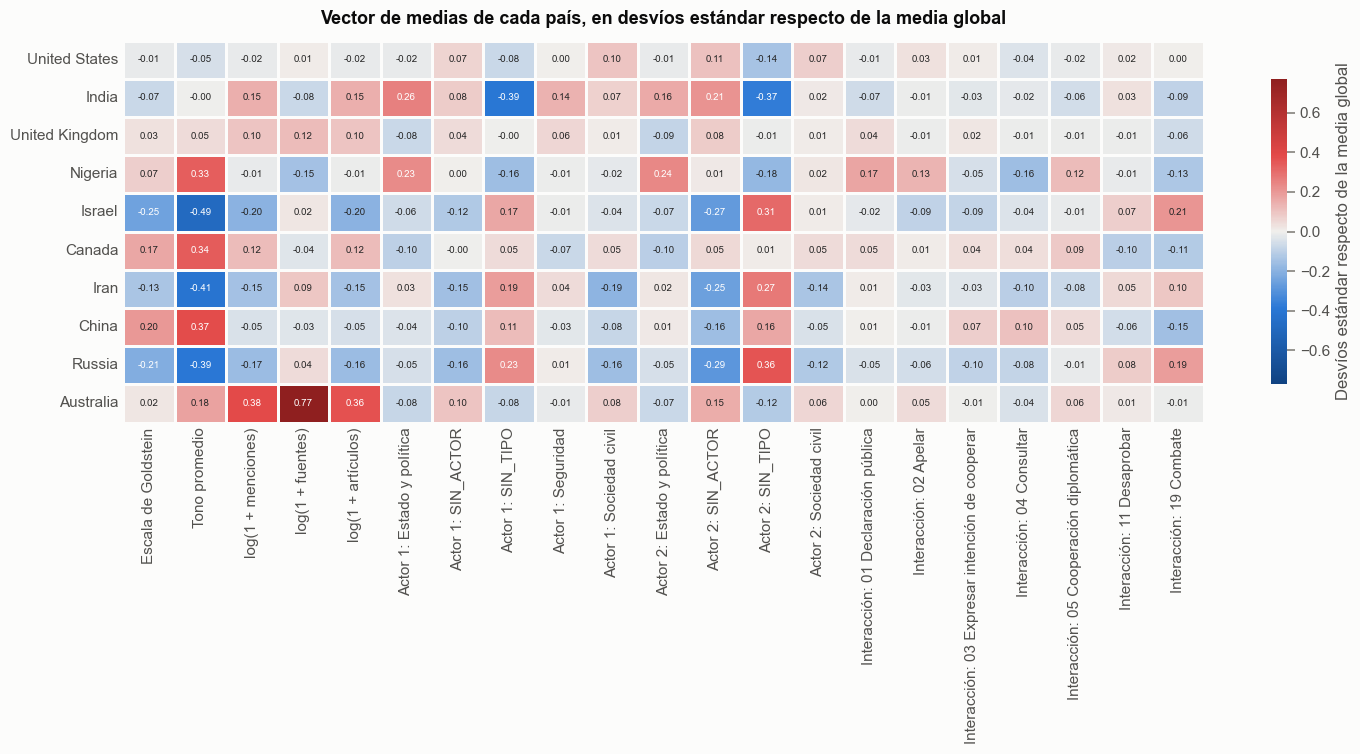

In [17]:
medias_estandarizadas = standardize_means(medias, perfil)
fig = plots.plot_mean_profiles(
    medias_estandarizadas.drop(GLOBAL),
    "Vector de medias de cada país, en desvíos estándar respecto de la media global",
)
plots.save_figure(fig, "vectores_medias")

**Perfiles por país.**

- **Israel, Irán y Rusia** tienen el tono más negativo (−0,4 a −0,5 desvíos), Goldstein por debajo del promedio y más combate (`19`, +0,10 a +0,21). También tienen más actores sin tipo y menos eventos sin actor 2: son eventos entre dos actores, en general países (p. ej. `ISR`, `IRN`), en lugar de actores con un rol definido. Es un perfil de **conflicto entre Estados**.
- **Canadá, China y Nigeria** están en el extremo opuesto del tono (+0,33 a +0,37). China y Canadá suman Goldstein alto y poco combate: un perfil **cooperativo/diplomático**. Nigeria tiene más declaraciones públicas y apelaciones (`01`, `02`).
- **India** se distingue por sus actores: muchos más actores de *Estado y política* (+0,26 en el actor 1) y muchos menos sin tipo (−0,39). La cobertura de India nombra funcionarios, partidos y organismos, no sólo al país.
- **Australia** se distingue por la cobertura: cada evento lo publican más fuentes (+0,77 desvíos) y tiene más menciones y artículos.
- **Estados Unidos y Reino Unido** están cerca de cero en casi todo. En el caso de Estados Unidos es en parte por construcción: aporta el 32% de los eventos, así que la media global se parece a la suya.

### 2.2 Distancias entre vectores de medias

Se calculan dos distancias entre todos los pares de vectores (global vs. país y país vs. país):

- **Euclídea estandarizada**: la distancia euclídea entre las medias estandarizadas de arriba. Cada variable pesa lo mismo, independientemente de su escala.
- **Mahalanobis**: usa la matriz de covarianza global de los eventos. Además de la escala, descuenta la redundancia entre variables correlacionadas. Por ejemplo, menciones y artículos miden casi lo mismo (*r* = 0,99, ver 2.3), y en la euclídea esa diferencia cuenta dos veces.

El mapa de calor ordena los vectores con un clustering jerárquico (enlace promedio), para que los vectores parecidos queden juntos.

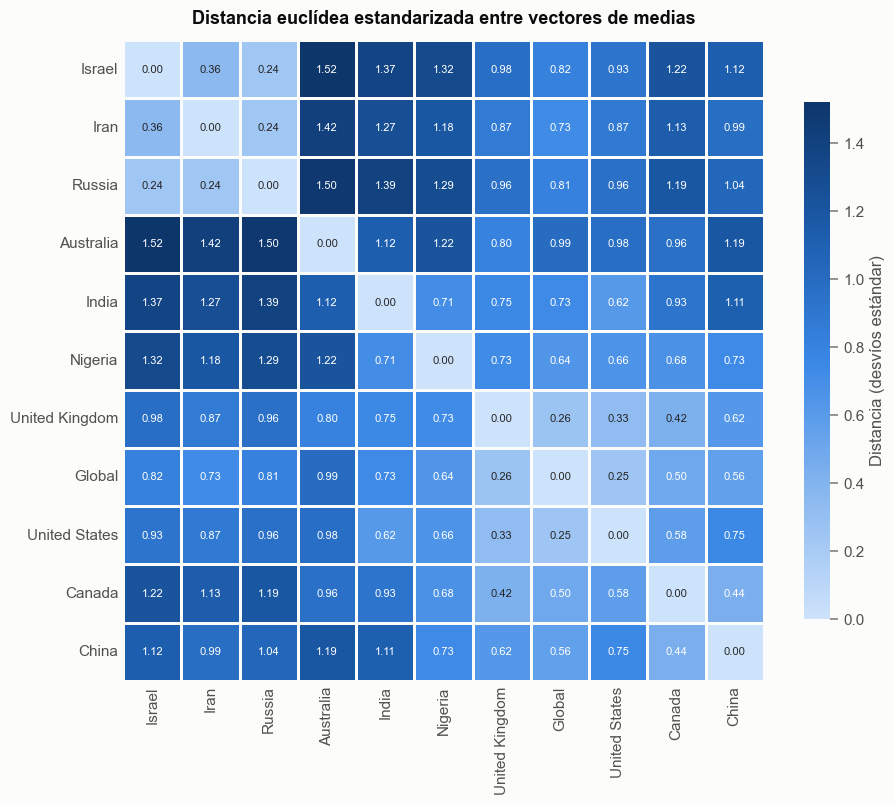

In [18]:
distancias = {
    "Euclídea estandarizada": distance_matrix(medias, perfil, "euclidean"),
    "Mahalanobis": distance_matrix(medias, perfil, "mahalanobis"),
}
fig = plots.plot_distance_matrix(
    distancias["Euclídea estandarizada"],
    "Distancia euclídea estandarizada entre vectores de medias",
    "Distancia (desvíos estándar)",
)
plots.save_figure(fig, "distancias_euclidea")

Correlación de Spearman entre los rankings de las dos métricas: 0.99


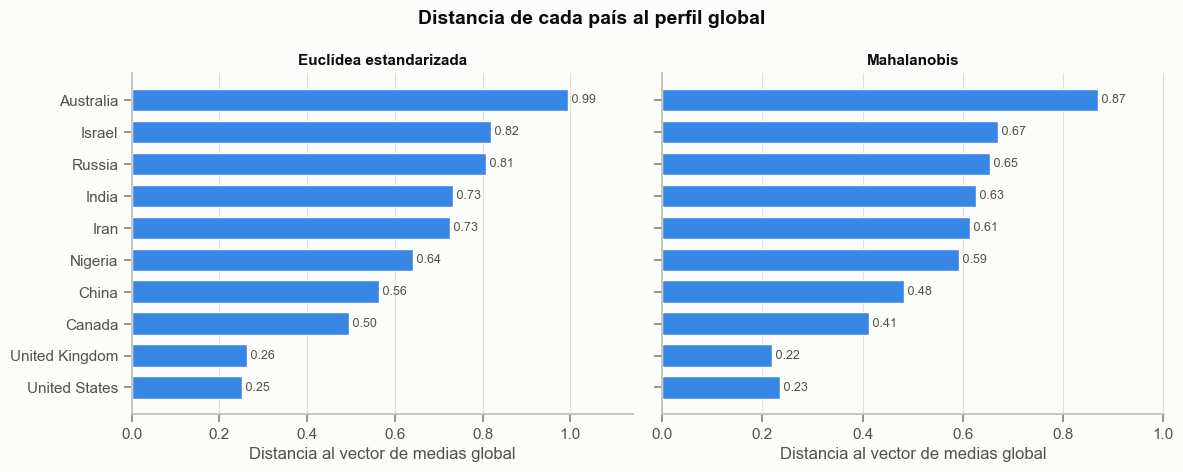

In [19]:
distancia_global = pd.DataFrame({metrica: d[GLOBAL] for metrica, d in distancias.items()}).drop(GLOBAL)
fig = plots.plot_global_distances(distancia_global)
plots.save_figure(fig, "distancias_global")

print("Correlación de Spearman entre los rankings de las dos métricas:",
      f"{distancia_global.corr(method='spearman').iloc[0, 1]:.2f}")

In [20]:
pares_paises = (
    distancias["Euclídea estandarizada"]
    .drop(index=GLOBAL, columns=GLOBAL)
    .where(lambda d: np.triu(np.ones(d.shape, dtype=bool), k=1))
    .stack()
    .rename("distancia")
    .sort_values()
)
pd.concat({"Más similares": pares_paises.head(5), "Más disímiles": pares_paises.tail(5)[::-1]}).to_frame().style.format(
    "{:.2f}"
).set_caption("Tabla 8. Pares de países más similares y más disímiles (euclídea estandarizada)")

**Global vs. país.** Los más cercanos al perfil global son Estados Unidos (0,25) y Reino Unido (0,26); los más lejanos, Australia (0,99), Israel (0,82) y Rusia (0,81). Mahalanobis da distancias algo menores, porque descuenta la redundancia entre menciones y artículos, pero ordena a los países casi igual (Spearman = 0,99): la conclusión no depende de la métrica.

**País vs. país.** El clustering separa tres grupos:

1. **Israel, Rusia e Irán**, el bloque más compacto (distancias de 0,24 a 0,36), con el perfil de conflicto descrito en 2.1.
2. **Reino Unido, Estados Unidos, Canadá y China** (0,33 a 0,75), cerca del perfil global y con Canadá y China en el extremo cooperativo.
3. **India, Nigeria y Australia**, cada uno lejos de los demás por un rasgo propio: los actores tipados de India, las declaraciones de Nigeria y la cobertura de Australia.

Los pares más disímiles enfrentan el bloque de conflicto con Australia e India (1,37 a 1,52). Con 21 variables, una distancia de 1,5 equivale, por ejemplo, a una diferencia de 0,33 desvíos en cada variable.

### 2.3 Matriz de correlaciones

**Global.** Se usa la matriz completa, incluidas las indicadoras de región. La correlación de Pearson entre dos indicadoras es el coeficiente φ de asociación entre dos variables binarias.

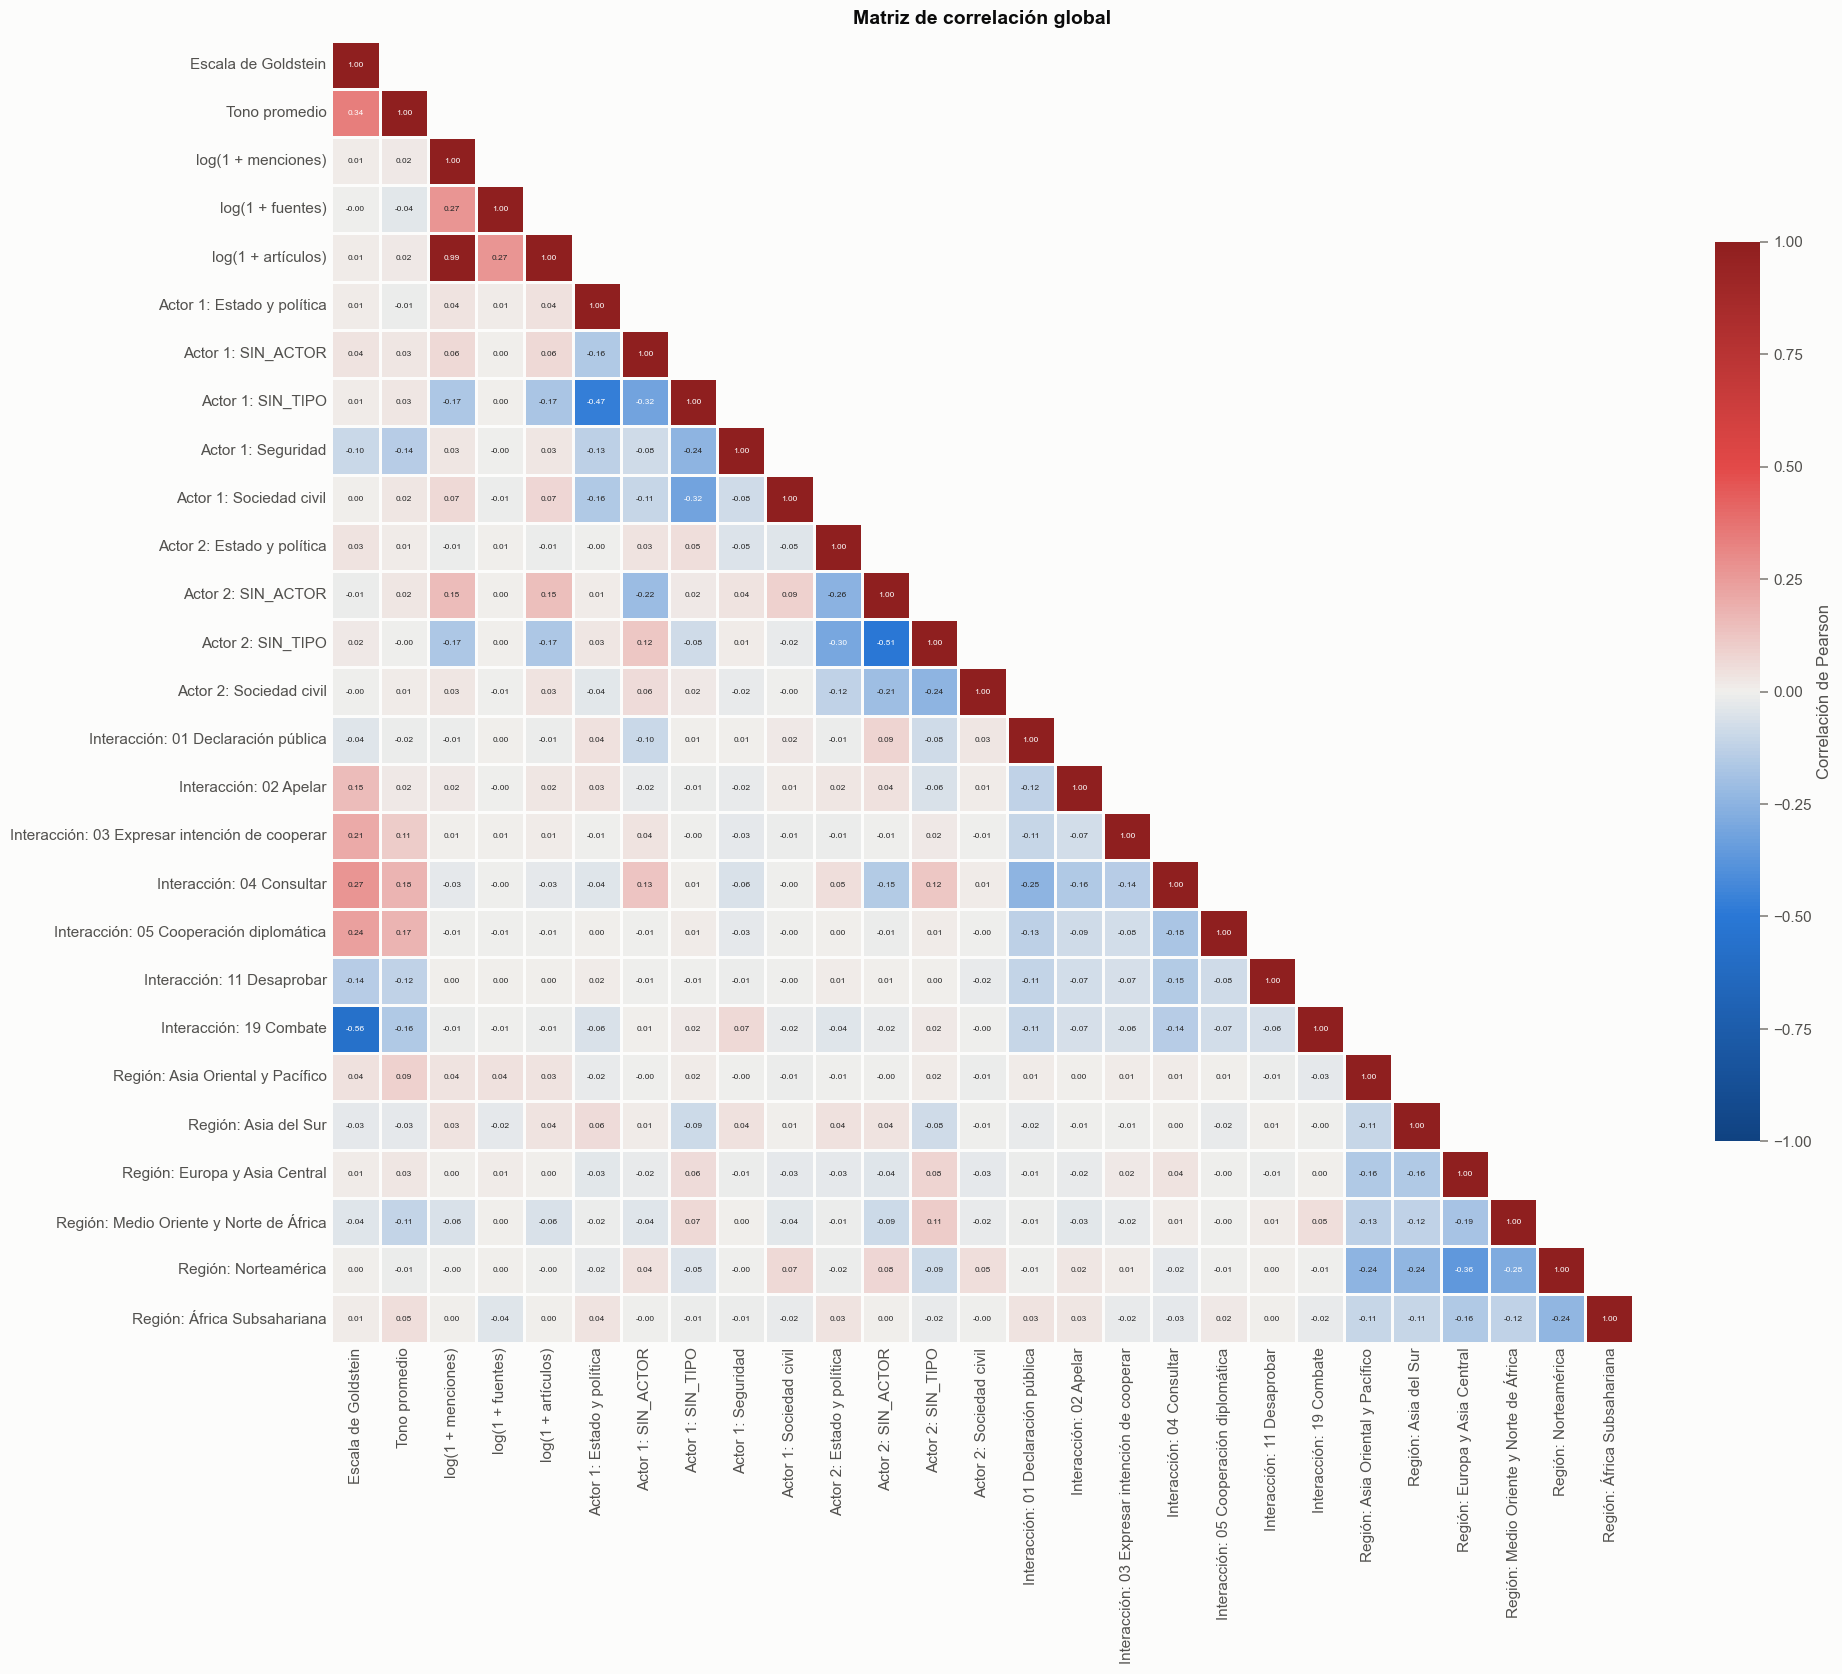

In [21]:
correlacion_global = matriz.corr()
fig = plots.plot_correlation_heatmap(correlacion_global, "Matriz de correlación global")
plots.save_figure(fig, "correlacion_global")

In [22]:
correlacion_perfil = perfil.corr()
pares = correlation_pairs(correlacion_global)
pares.assign(
    variable_1=pares["variable_1"].map(variable_label),
    variable_2=pares["variable_2"].map(variable_label),
).head(15).style.format({"r": "{:.2f}"}).set_caption(
    "Tabla 9. Pares de variables con mayor |r| a nivel global"
).hide(axis="index")

variable_1,variable_2,r
log(1 + menciones),log(1 + artículos),0.99
Escala de Goldstein,Interacción: 19 Combate,-0.56
Escala de Goldstein,Tono promedio,0.34
log(1 + fuentes),log(1 + artículos),0.27
log(1 + menciones),log(1 + fuentes),0.27
Escala de Goldstein,Interacción: 04 Consultar,0.27
Escala de Goldstein,Interacción: 05 Cooperación diplomática,0.24
Actor 1: SIN_ACTOR,Actor 2: SIN_ACTOR,-0.22
Escala de Goldstein,Interacción: 03 Expresar intención de cooperar,0.21
Tono promedio,Interacción: 04 Consultar,0.18


La Tabla 9 excluye los pares de indicadoras de una misma variable categórica (p. ej. dos categorías del actor 2), porque se excluyen mutuamente y su correlación es negativa por construcción. En el mapa de calor aparecen como los bloques azules sobre la diagonal (p. ej. *Actor 2: SIN_ACTOR* ~ *Actor 2: SIN_TIPO*, −0,51).

**Interpretación.**

- **Cobertura.** Menciones y artículos están casi perfectamente correlacionados (0,99): cada mención es en la práctica un artículo distinto, así que son la misma variable. Las fuentes se asocian con ambas, pero mucho menos (0,27): un evento puede sumar muchos artículos de pocos medios.
- **Goldstein e interacción.** Goldstein es negativo en el combate (−0,56) y positivo en consultas, cooperación diplomática e intención de cooperar (0,21 a 0,27). Esto es en buena parte por construcción: GDELT asigna Goldstein a partir del código CAMEO del evento, así que mide lo mismo que la interacción, en una escala continua.
- **Goldstein y tono** (0,34). Es la asociación más interesante entre continuas, porque las dos se calculan por separado: Goldstein sale del código del evento y el tono, del texto del artículo. Los eventos de conflicto se cuentan con un lenguaje más negativo, pero la asociación es moderada.
- **La cobertura no depende del signo del evento.** Menciones, fuentes y artículos casi no se correlacionan con el tono ni con Goldstein (|*r*| < 0,05): en esta muestra un conflicto no recibe más cobertura que una cooperación.
- **Actores.** Los eventos con actores sin tipo tienen algo menos de menciones (−0,17).
- **Región.** Todas sus correlaciones son débiles (|*r*| ≤ 0,11); la más fuerte es el tono más negativo en Medio Oriente y Norte de África (−0,11).

Fuera de esos pares, casi todas las correlaciones están entre −0,15 y 0,15. Las variables comparten poca información, algo esperable en un flujo ruidoso y disperso como GDELT.

**Por país.** Las matrices por país usan el perfil del evento (sin región), con las mismas variables y el mismo orden que la global.

,diferencia_rms
United Kingdom,0.021
United States,0.022
Canada,0.026
Iran,0.033
Israel,0.034
China,0.035
Russia,0.039
India,0.039
Nigeria,0.040
Australia,0.041


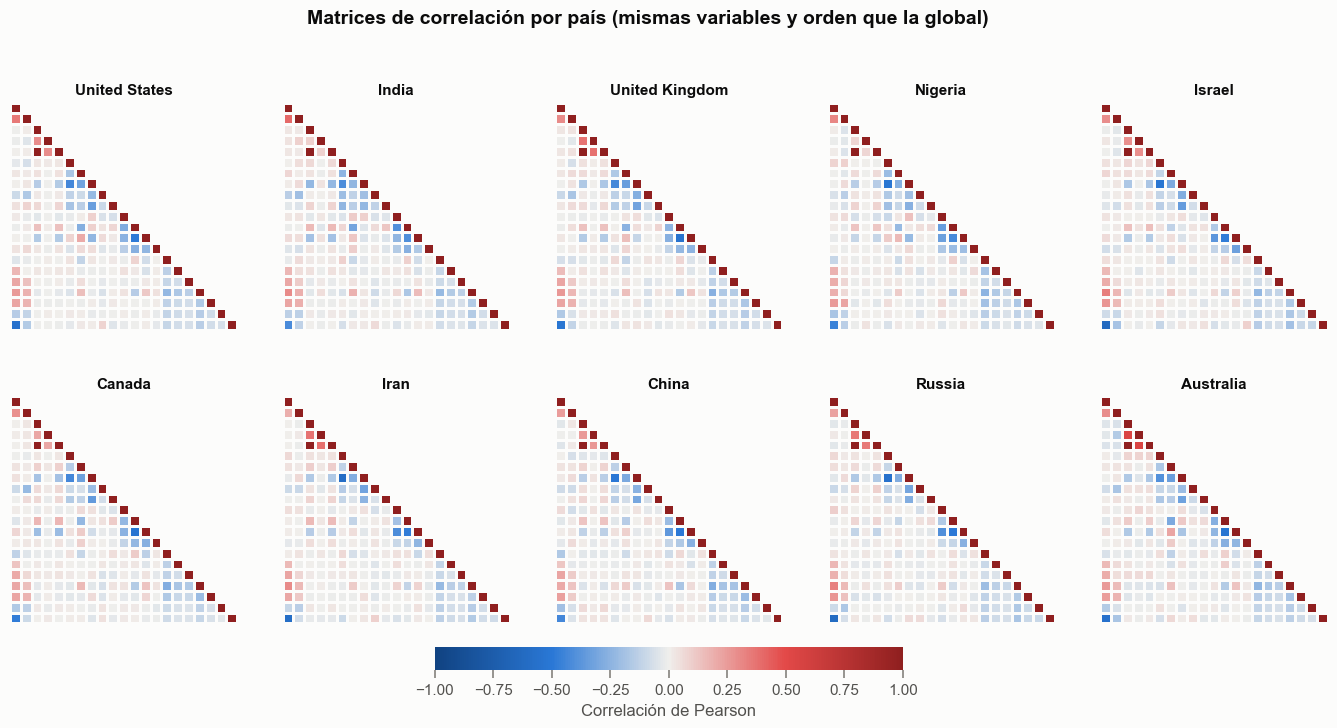

In [23]:
correlaciones_pais = country_correlations(perfil, pais_evento, paises_top)
fig = plots.plot_country_correlation_grid(correlaciones_pais)
plots.save_figure(fig, "correlacion_paises")

correlation_distance(correlaciones_pais, correlacion_perfil).to_frame().style.format("{:.3f}").set_caption(
    "Tabla 10. Diferencia típica (RMS) entre la correlación de cada país y la global"
)

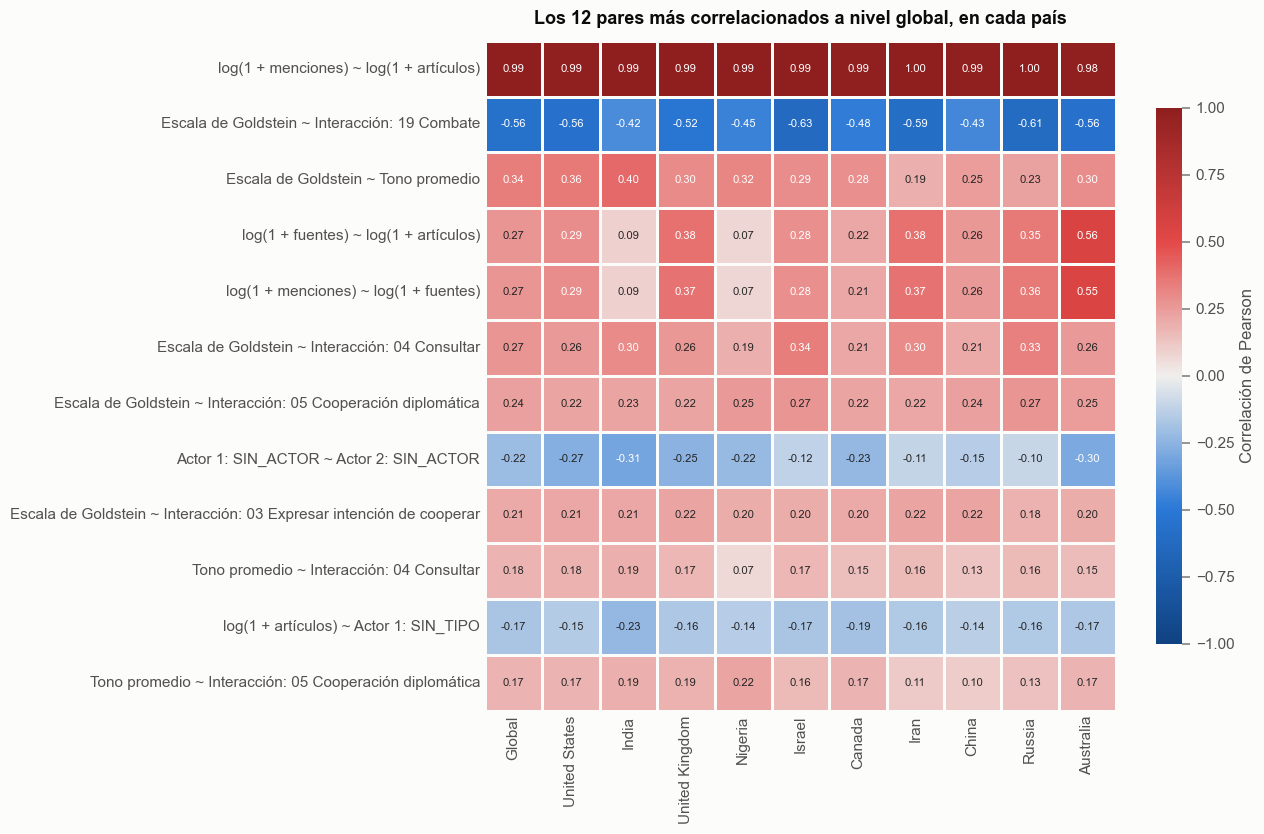

In [24]:
pares_perfil = correlation_pairs(correlacion_perfil).head(12)
fig = plots.plot_pairs_by_country(
    pairs_by_country(pares_perfil, correlacion_perfil, correlaciones_pais),
    "Los 12 pares más correlacionados a nivel global, en cada país",
)
plots.save_figure(fig, "correlacion_pares_paises")

La estructura de correlación es **muy estable entre países**: la diferencia típica con la matriz global está entre 0,02 (Reino Unido, Estados Unidos) y 0,04 (Nigeria, Australia), y los 12 pares más fuertes tienen el mismo signo en los 10 países. Las asociaciones de 2.3 son entonces propiedades de cómo GDELT codifica y cubre los eventos, no de un país en particular. Las diferencias están en la intensidad:

- **Fuentes y artículos**: 0,56 en Australia, pero 0,09 en India y 0,07 en Nigeria. En estos dos países un evento acumula artículos sin sumar medios: la cobertura está concentrada en pocas fuentes.
- **Goldstein y combate**: más fuerte en Israel (−0,63) y Rusia (−0,61) que en India (−0,42) y China (−0,43).
- **Goldstein y tono**: más débil en Irán (0,19) y Rusia (0,23) que en India (0,40). En la cobertura de Irán y Rusia, el tono del texto acompaña menos al carácter cooperativo o conflictivo del evento.
- **Ausencia de actores** (*Actor 1: SIN_ACTOR* ~ *Actor 2: SIN_ACTOR*): débil en Israel, Irán y Rusia (−0,10 a −0,12), donde los eventos con un único actor son menos frecuentes.

## Actividad 3: Reducción de dimensionalidad e interpretación de componentes

### 3.1 Ajuste del modelo

El ACP se ajusta sobre la matriz de datos completa (incluidas las indicadoras de región), con cada variable estandarizada (media 0, desvío 1). Así se diagonaliza la matriz de correlación y ninguna variable domina por su escala: sin estandarizar, el tono y Goldstein (desvío ≈ 4) se llevarían casi toda la varianza frente a las indicadoras (desvío ≤ 0,5).

Se deja afuera `log(1 + artículos)`: su correlación con `log(1 + menciones)` es 0,99 (ver 2.3), así que son la misma variable. Con las dos, la cobertura pesaría el doble y formaría una componente propia sólo por esa redundancia.

In [25]:
datos_acp = matriz.drop(columns=PCA_EXCLUDED)
acp = run_pca(datos_acp)
print(f"ACP sobre {datos_acp.shape[0]:,} eventos x {datos_acp.shape[1]} variables estandarizadas")
acp.variance_table().style.format(
    {"autovalor": "{:.3f}", "var_explicada": "{:.1%}", "var_acumulada": "{:.1%}"}
).set_caption("Tabla 11. Autovalores y varianza explicada")

ACP sobre 168,959 eventos x 26 variables estandarizadas


,autovalor,var_explicada,var_acumulada
PC1,2.075,8.0%,8.0%
PC2,1.869,7.2%,15.2%
PC3,1.675,6.4%,21.6%
PC4,1.449,5.6%,27.2%
PC5,1.338,5.1%,32.3%
PC6,1.318,5.1%,37.4%
PC7,1.194,4.6%,42.0%
PC8,1.171,4.5%,46.5%
PC9,1.169,4.5%,51.0%
PC10,1.155,4.4%,55.4%


### 3.2 Varianza explicada

Con 26 variables estandarizadas la varianza total es 26, y una componente con autovalor 1 explica lo mismo que una variable sola. El espectro es muy plano: PC1 explica sólo el 8,0% y hacen falta 16 componentes para llegar al 80%. Es lo opuesto a Iris o Wine, donde 2 componentes resumían la mayor parte de la varianza. Las variables de GDELT comparten poca información (casi todas las correlaciones de 2.3 están entre −0,15 y 0,15), así que cada una aporta en buena medida una dimensión propia.

**El criterio de Kaiser cuenta de más.** Las últimas componentes (PC23 a PC26) tienen autovalores casi nulos, y cada una carga sobre las indicadoras de una sola variable categórica (Tabla 12; PC23, además, sobre Goldstein, que GDELT calcula a partir del código de la interacción). Son las "dimensiones nulas" de la codificación indicadora: como `OTHER` (la referencia) es chica, las indicadoras restantes de cada variable casi suman 1 y son casi colineales. Como los autovalores siempre suman 26, la varianza que les falta a esas componentes se reparte entre las demás y empuja a muchas por encima de 1, aunque no representen ninguna asociación entre variables.

In [26]:
acp.loadings.iloc[:, -4:].rename(index=variable_label).style.format("{:.2f}").background_gradient(
    cmap=plots.DIVERGING_CMAP, vmin=-1, vmax=1
).set_caption("Tabla 12. Loadings de las 4 últimas componentes (dimensiones nulas)")

,PC23,PC24,PC25,PC26
Escala de Goldstein,-0.23,0.00,0.00,-0.00
Tono promedio,-0.02,-0.01,0.00,-0.00
log(1 + menciones),0.01,0.01,0.01,0.00
log(1 + fuentes),-0.00,-0.00,-0.00,-0.00
Actor 1: Estado y política,0.00,-0.01,0.15,0.00
Actor 1: SIN_ACTOR,0.00,0.00,0.12,0.00
Actor 1: SIN_TIPO,0.01,-0.00,0.19,0.00
Actor 1: Seguridad,0.01,-0.01,0.09,0.00
Actor 1: Sociedad civil,0.00,-0.01,0.12,0.00
Actor 2: Estado y política,-0.00,0.16,0.00,0.00


Para separar la asociación real de esa estructura mecánica se usa un **análisis paralelo de Horn**. Se permutan las filas de cada variable original por separado (las indicadoras de una misma variable, juntas), lo que destruye toda asociación entre variables pero conserva la distribución de cada una y la colinealidad de sus indicadoras. Los autovalores de esos datos permutados son el nulo: lo que se obtendría sin ninguna asociación. Una componente aporta estructura real sólo si su autovalor supera al nulo.

In [27]:
paralelo = parallel_analysis(datos_acp, datos_acp.columns.to_series().map(source_variable))
criterios = retention_criteria(acp, paralelo)

display(criterios.to_frame().style.set_caption("Tabla 13. Componentes retenidas por cada criterio"))
paralelo.head(12).style.format("{:.3f}").set_caption(
    "Tabla 14. Análisis paralelo: autovalor de los datos frente al nulo (20 permutaciones)"
)

,componentes
Kaiser (autovalor > 1),17
70% de varianza acumulada,14
80% de varianza acumulada,16
Análisis paralelo (autovalor > nulo),10


,autovalor,nulo_media,nulo_p95,exceso
PC1,2.075,1.545,1.545,0.530
PC2,1.869,1.512,1.513,0.356
PC3,1.675,1.411,1.412,0.264
PC4,1.449,1.268,1.268,0.181
PC5,1.338,1.231,1.232,0.106
PC6,1.318,1.198,1.199,0.119
PC7,1.194,1.177,1.178,0.016
PC8,1.171,1.146,1.147,0.024
PC9,1.169,1.132,1.133,0.036
PC10,1.155,1.118,1.120,0.034


Incluso sin ninguna asociación entre variables, la primera componente nula tiene autovalor 1,55: es la correlación negativa, por construcción, entre las indicadoras de una misma variable. El análisis paralelo retiene 10 componentes, pero el **exceso sobre el nulo** muestra un corte claro después de la sexta: de PC1 a PC6 el exceso va de 0,53 a 0,11, y de PC7 a PC10 cae por debajo de 0,04. Con 169 mil eventos, esos cuatro excesos chicos son estadísticamente distinguibles del nulo, pero su peso es despreciable.

**Se retienen 6 componentes**, que explican el 37% de la varianza total. Es el mismo punto donde el scree plot pasa de las componentes que se despegan a la meseta (de 1,32 a 1,19). La respuesta a la pregunta 4 tiene entonces dos partes:

- Si la pregunta es **cuántas componentes resumen la varianza total**, la respuesta es que ninguna cantidad chica lo hace: el 80% requiere 16 de 26 componentes.
- Si la pregunta es **cuántas componentes capturan la estructura de asociación entre variables**, la respuesta es 6. El resto de la varianza es propia de cada variable, o es la estructura mecánica de las indicadoras.

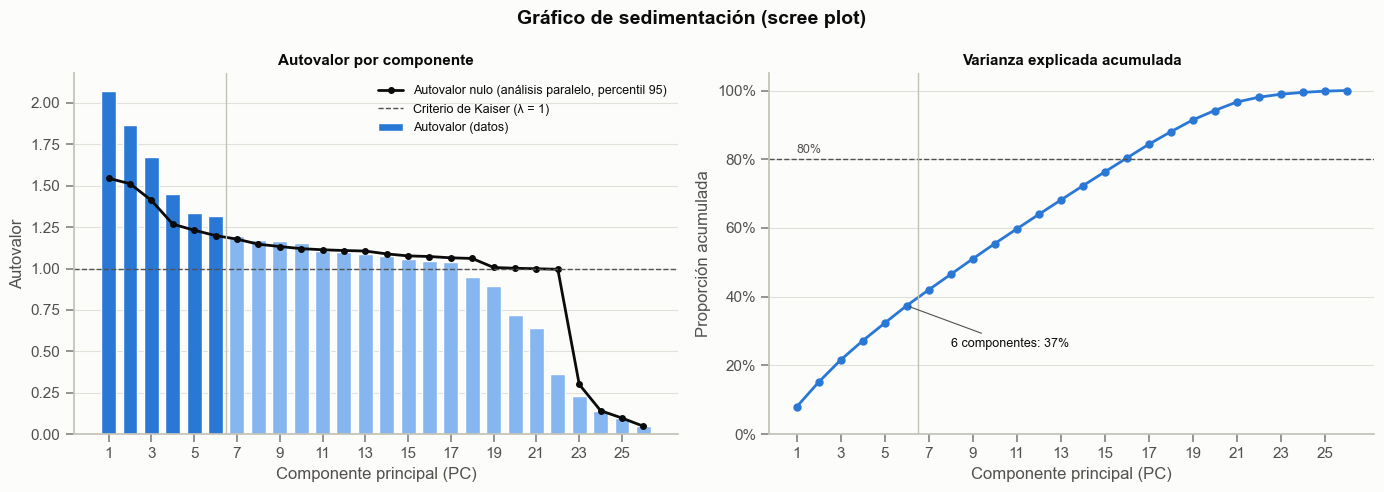

In [28]:
N_COMPONENTES = 6
fig = plots.plot_scree(paralelo, acp.var_exp, N_COMPONENTES)
plots.save_figure(fig, "scree_plot")

### 3.3 Interpretación de las componentes

Los loadings son la correlación entre cada variable y cada componente. Para nombrar una componente se miran las variables con mayor |loading| y el signo con que entran.

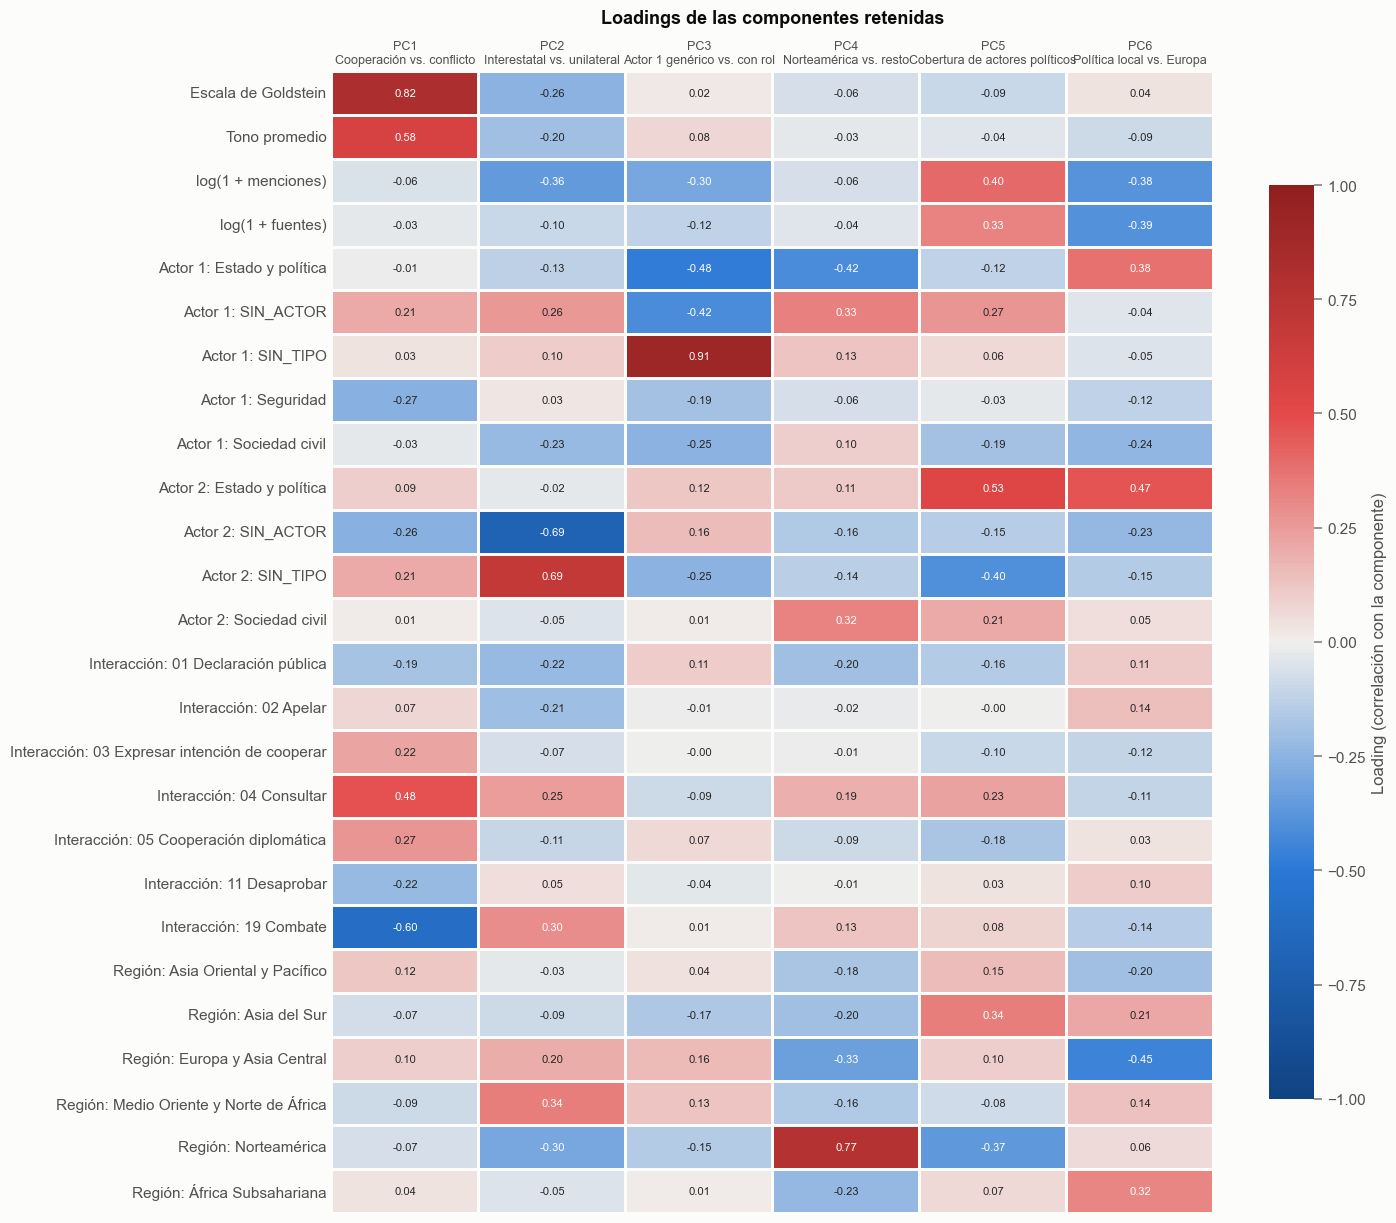

In [29]:
NOMBRES_COMPONENTES = {
    "PC1": "Cooperación vs. conflicto",
    "PC2": "Interestatal vs. unilateral",
    "PC3": "Actor 1 genérico vs. con rol",
    "PC4": "Norteamérica vs. resto",
    "PC5": "Cobertura de actores políticos",
    "PC6": "Política local vs. Europa",
}
fig = plots.plot_loadings(acp.loadings.iloc[:, :N_COMPONENTES], NOMBRES_COMPONENTES)
plots.save_figure(fig, "loadings")

**Tabla 15.** Nombre conceptual de cada componente retenida.

| PC | Var. | Nombre | Polo positivo (loading) | Polo negativo (loading) |
|---|---|---|---|---|
| PC1 | 8,0% | **Cooperación vs. conflicto** | Goldstein (0,82), tono (0,58), consultar (0,48), cooperación diplomática (0,27), intención de cooperar (0,22) | Combate (−0,60), actor 1 de seguridad (−0,27), desaprobar (−0,22) |
| PC2 | 7,2% | **Interestatal vs. unilateral** | Actor 2 sin tipo (0,69), Medio Oriente y Norte de África (0,34), combate (0,30), actor 1 ausente (0,26), consultar (0,25) | Sin actor 2 (−0,69), menciones (−0,36), Norteamérica (−0,30), Goldstein (−0,26), actor 1 de sociedad civil (−0,23) |
| PC3 | 6,4% | **Actor 1 genérico vs. con rol** | Actor 1 sin tipo (0,91) | Actor 1 de Estado y política (−0,48), actor 1 ausente (−0,42), menciones (−0,30), actor 1 de sociedad civil (−0,25) |
| PC4 | 5,6% | **Norteamérica vs. resto** | Norteamérica (0,77), actor 1 ausente (0,33), actor 2 de sociedad civil (0,32) | Actor 1 de Estado y política (−0,42), Europa y Asia Central (−0,33), África Subsahariana (−0,23) |
| PC5 | 5,1% | **Cobertura de actores políticos** | Actor 2 de Estado y política (0,53), menciones (0,40), Asia del Sur (0,34), fuentes (0,33) | Actor 2 sin tipo (−0,40), Norteamérica (−0,37) |
| PC6 | 5,1% | **Política local vs. Europa** | Actor 2 (0,47) y actor 1 (0,38) de Estado y política, África Subsahariana (0,32) | Europa y Asia Central (−0,45), fuentes (−0,39), menciones (−0,38) |

- **PC1, cooperación vs. conflicto.** Es el eje del *carácter* del evento. Junta las dos medidas continuas de cooperación (Goldstein y tono) con las interacciones cooperativas, frente al combate. Retoma las correlaciones más fuertes de 2.3 (Goldstein ~ combate, Goldstein ~ tono) y es la componente que mejor responde la pregunta de cómo se diferencian los eventos.
- **PC2, interestatal vs. unilateral.** En el polo positivo están los eventos entre dos actores genéricos (en general dos países), en Medio Oriente y con más combate. En el negativo, los eventos de un solo actor (sin actor 2), más mencionados y en Norteamérica. Separa la noticia internacional de conflicto de la noticia doméstica.
- **PC3, actor 1 genérico vs. con rol.** Distingue si el actor principal se identifica sólo por su país o con un rol (gobierno, sociedad civil). Los eventos con actores con rol tienen más menciones.
- **PC4, Norteamérica vs. resto.** Es sobre todo geográfica: separa los eventos en Norteamérica (con actores de sociedad civil) de los de Europa y África, con más actores políticos.
- **PC5 y PC6, cobertura y política.** Tienen autovalores casi iguales (1,34 y 1,32). Cuando dos autovalores son tan parecidos, la orientación de cada componente dentro del plano que forman es inestable: otra muestra podría rotarlas. Conviene leerlas juntas: combinan la **cobertura** (menciones y fuentes) con la presencia de **actores de Estado y política** y con la región. En PC5 la cobertura y los actores políticos van juntos (Asia del Sur); en PC6 se oponen: política local de África Subsahariana con poca cobertura, frente a eventos europeos con muchas fuentes.

Las tres primeras componentes describen sobre todo el evento: su carácter y la estructura de sus actores. La región aparece con loadings moderados en PC2 y domina recién en PC4. El tipo de evento varía más que el lugar donde ocurre.

### 3.4 Biplot

Con 169 mil eventos, un gráfico de puntos se satura, así que la nube se muestra como **densidad** (hexágonos, escala logarítmica). Las flechas son los loadings de las variables con |loading| ≥ 0,35 en el plano. Los outliers multivariantes se marcan en naranja (ver más abajo).

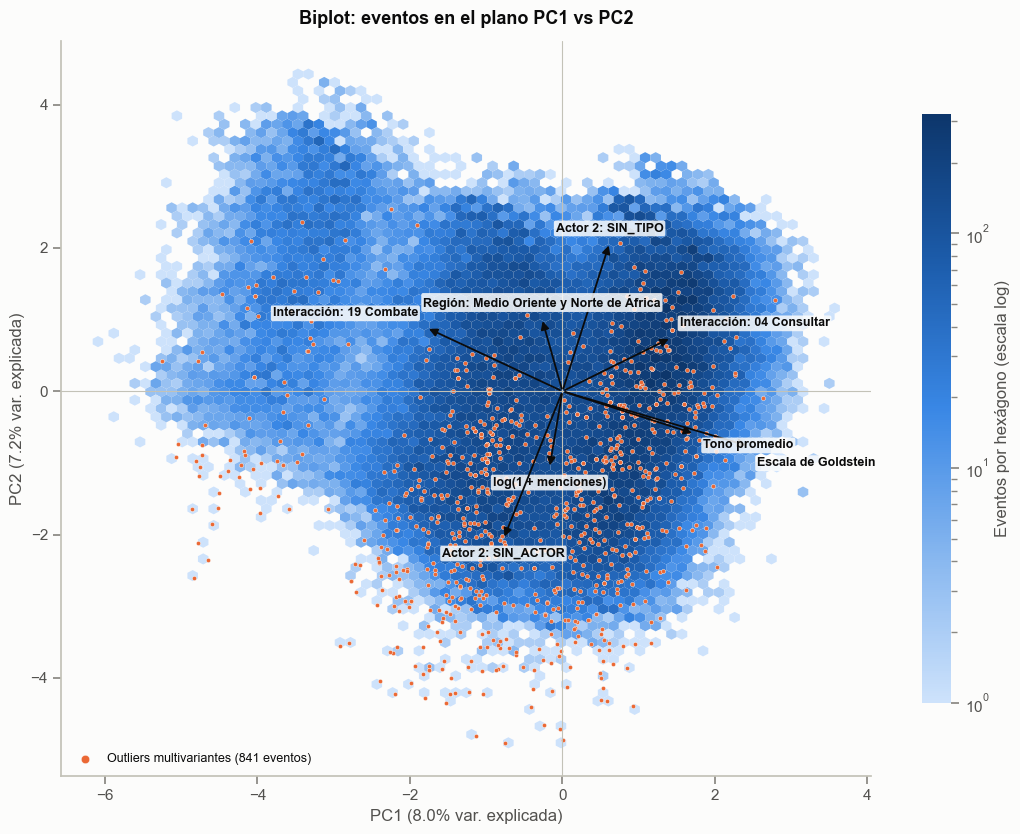

In [30]:
d2, umbral = multivariate_outliers(acp, N_COMPONENTES)
es_outlier = d2 > umbral

fig = plots.plot_biplot(acp.scores, acp.loadings, acp.var_exp, es_outlier)
plots.save_figure(fig, "biplot")

Para ver dónde caen los grupos de las actividades anteriores, se proyecta el score medio de cada país (los mismos 10 de la actividad 2) y de cada tipo de interacción.

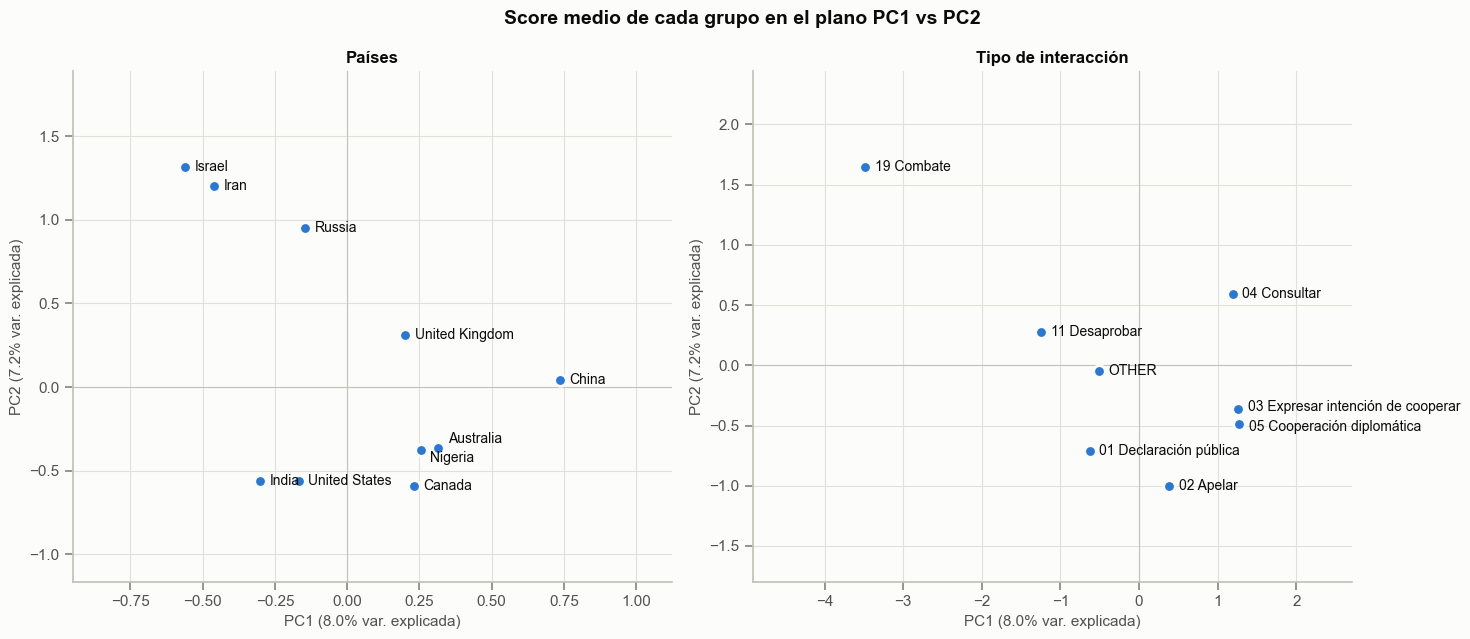

In [31]:
centroides_pais = acp.scores.groupby(pais_evento.to_numpy()).mean().loc[paises_top.index]
centroides_pais.index = paises_top.to_numpy()

centroides_interaccion = acp.scores.groupby(eventos_reducidos["interaccion"].to_numpy()).mean()
centroides_interaccion.index = [
    f"{codigo} {CAMEO_ROOT_LABELS.get(codigo, '')}".strip() for codigo in centroides_interaccion.index
]

fig = plots.plot_group_centroids(
    {"Países": centroides_pais, "Tipo de interacción": centroides_interaccion}, acp.var_exp
)
plots.save_figure(fig, "centroides")

**Agrupamientos.** La nube no se parte en grupos separados. Es una sola masa continua, porque las 4 variables continuas rellenan los huecos entre las combinaciones de las 22 indicadoras. Lo que sí hay es una **estructura de dos ejes** que ordena a los grupos:

- **Horizontal (PC1)**: el combate queda solo en el extremo izquierdo (score medio −3,5), lejos de todas las demás interacciones. Del lado derecho se agrupan las interacciones cooperativas: consultar, cooperación diplomática e intención de cooperar (+1,2 a +1,3). Desaprobar y las declaraciones públicas quedan en el medio.
- **Vertical (PC2)**: los países se ordenan casi como en el clustering de la actividad 2. Israel, Irán y Rusia (bloque de conflicto) quedan arriba (+0,95 a +1,31) y a la izquierda; Estados Unidos, India, Canadá, Nigeria y Australia, abajo (−0,36 a −0,59). China es el país más hacia el polo cooperativo de PC1 (+0,73).

Los dos primeros ejes recuperan la topología de la actividad 2: el bloque de conflicto entre Estados frente al resto. Pero los centroides de los países están mucho más cerca entre sí que los de las interacciones: lo que más diferencia a un evento es *qué* pasó, no *dónde*.

**Outliers multivariantes.** Se mide la distancia de Mahalanobis de cada evento en las 6 componentes retenidas. Si los scores fueran normales, seguiría una χ² con 6 grados de libertad, y se marca como outlier todo evento por encima de su percentil 99,9.

Umbral: 22.5. Outliers: 841 eventos (0.50%); bajo normalidad se esperarían 169 (0,1%)


,Outliers,Resto
Eventos,841,"168,118"
Menciones (mediana),28.00,4.00
Fuentes (mediana),6.00,1.00
Eventos con más de 1 fuente,99.5%,2.7%
Tono (media),-3.34,-2.00
Goldstein (media),-0.36,0.48
Región: Asia Oriental y Pacífico,31.7%,9.7%


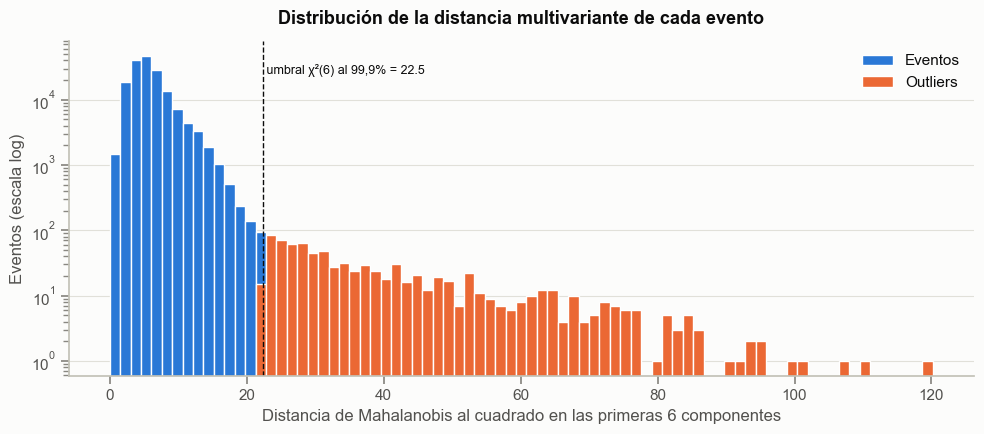

In [32]:
fig = plots.plot_outlier_distances(d2, umbral, N_COMPONENTES)
plots.save_figure(fig, "outliers")

print(f"Umbral: {umbral:.1f}. Outliers: {es_outlier.sum():,} eventos ({es_outlier.mean():.2%}); "
      f"bajo normalidad se esperarían {0.001 * len(es_outlier):.0f} (0,1%)")

eventos_indexados = eventos_reducidos.set_index("evento_id")
comparacion = pd.DataFrame(
    {
        grupo: {
            "Eventos": len(sub),
            "Menciones (mediana)": np.expm1(sub["log_menciones"]).median(),
            "Fuentes (mediana)": np.expm1(sub["log_fuentes"]).median(),
            "Eventos con más de 1 fuente": (sub["log_fuentes"] > np.log1p(1)).mean(),
            "Tono (media)": sub["tono"].mean(),
            "Goldstein (media)": sub["goldstein"].mean(),
            "Región: Asia Oriental y Pacífico": (sub["region"] == "Asia Oriental y Pacífico").mean(),
        }
        for grupo, sub in {
            "Outliers": eventos_indexados[es_outlier.to_numpy()],
            "Resto": eventos_indexados[~es_outlier.to_numpy()],
        }.items()
    }
)
comparacion.style.format("{:,.2f}").format("{:,.0f}", subset=pd.IndexSlice[["Eventos"], :]).format(
    "{:.1%}", subset=pd.IndexSlice[["Eventos con más de 1 fuente", "Región: Asia Oriental y Pacífico"], :]
).set_caption("Tabla 16. Outliers multivariantes frente al resto de los eventos")

La cola es mucho más pesada que la de una normal: hay 841 outliers (0,50%), cinco veces los esperados. No son errores sino los eventos de **cobertura excepcional**. En el resto de los eventos la mediana es de 1 fuente y 4 menciones, y sólo el 2,7% tiene más de una fuente. En los outliers la mediana es de 6 fuentes y 28 menciones, y el 99,5% tiene más de una fuente. Su tono es además más negativo, y están sobrerrepresentados en Asia Oriental y Pacífico (32% frente a 10%), la región de Australia, el país con más fuentes por evento en la actividad 2.

En el biplot casi no se distinguen: caen dentro de la nube, porque lo que los hace extremos es la cobertura, y la cobertura carga sobre PC5 y PC6, no sobre PC1 y PC2. Es un recordatorio de que el plano PC1–PC2 sólo muestra el 15% de la varianza: un evento puede ser atípico en dimensiones que ese plano no ve.

## Conclusiones

1. **Perfil multivariante.** El evento típico es levemente cooperativo, con tono negativo, poca cobertura (una fuente) y, en la mitad de los casos, con actores identificados sólo por su país. Los vectores de medias por país se separan sobre todo por el carácter del evento (tono, Goldstein, combate) y por cómo se identifica a los actores.
2. **Topología de cobertura.** Israel, Irán y Rusia forman un bloque compacto de conflicto entre Estados. Estados Unidos y Reino Unido están cerca del perfil global; Canadá y China, en el extremo cooperativo. Australia (cobertura) e India (actores con rol político) son los más distintos. La conclusión no depende de usar la distancia euclídea o la de Mahalanobis.
3. **Estructura de correlación.** Las asociaciones son pocas y en general débiles. Las fuertes son menciones ~ artículos (redundantes), Goldstein ~ combate y Goldstein ~ tono. La estructura es casi la misma en los 10 países analizados.
4. **Compresión.** El ecosistema de noticias no se deja comprimir: hacen falta 16 de 26 componentes para el 80% de la varianza. Una vez descontada la estructura mecánica de las indicadoras, 6 componentes capturan la asociación entre variables (37% de la varianza): cooperación vs. conflicto, interestatal vs. unilateral, identificación del actor, Norteamérica vs. resto, y dos componentes de cobertura y política.